In [1]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
perturbed_directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_PERTURB_0.3";
quiescent_directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_QUIESCENT_0.3";
perturbed_data_arrays = reader.fetch_phi2D_data(perturbed_directory_path, parallelise = True);
quiescent_data_arrays = reader.fetch_phi2D_data(quiescent_directory_path, parallelise = True);
dt_diag = reader.fetch_dt_diag(perturbed_directory_path);
jacobian_dictionary = reader.fetch_jacobian(perturbed_directory_path);

Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 368 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1170 out of 1201 | elapsed:    4.5s remaining:    0.1s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    4.6s finished


Finished compiling data from all files in the directory.
Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    4.2s finished


Finished compiling data from all files in the directory.


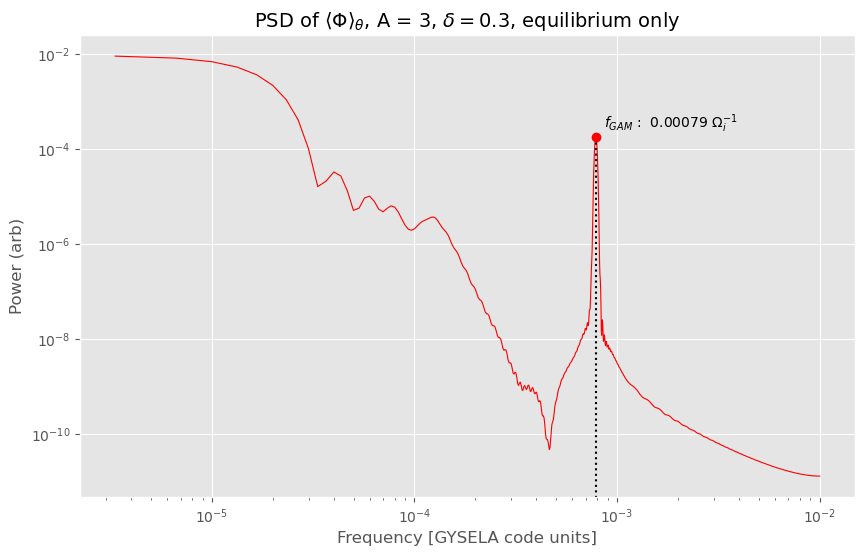

In [3]:
def plot_power_spectrum_density(phi2D_list, dt_diag, jacobian_dictionary, effective_radius = 0.7, title_suffix = "", real_frequency = False, quiescent_phi2D_list = None):

	# Signal isolation and data processing.
	# Logic here is similar to that of `extract_GAM_frequency` in the utilities.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary, effective_radius);

	if quiescent_phi2D_list is not None:
		quiescent_time_series = utils.generate_poloidally_averaged_time_series(quiescent_phi2D_list, jacobian_dictionary, effective_radius);
		radial_time_series = radial_time_series - quiescent_time_series;

	frequencies, power_spectrum_density = utils.map_power_spectrum(radial_time_series, dt_diag);
	frequencies = utils.convert_to_real_frequency(frequencies) if real_frequency else frequencies;
	GAM_peak_index = utils.isolate_GAM_peak_index(power_spectrum_density, frequencies);
	GAM_frequency = frequencies[GAM_peak_index];
	GAM_power = float(power_spectrum_density[GAM_peak_index]);
	
	# Figure plotting logic.
	plt.figure(figsize = (10, 6));
	plt.loglog(frequencies, power_spectrum_density, label = "PSD", color = "red", lw = 0.8);
	plt.vlines(GAM_frequency, GAM_power, 0, colors = "black", linestyles = "dotted");
	plt.plot(GAM_frequency, power_spectrum_density[GAM_peak_index], "ro");
	plt.annotate(rf"$f_{{GAM}}$ : {GAM_frequency : .5f} $\Omega_i^{{-1}}$", xy = (GAM_frequency, GAM_power), xytext = (GAM_frequency * 1.1, GAM_power * 1.5));
	plt.xlabel("Frequency [Hz]" if real_frequency else f"Frequency [GYSELA code units]");	
	plt.ylabel("Power (arb)");
	plt.title(rf"PSD of $\langle \Phi \rangle_\theta$, {title_suffix}", fontsize = 14);
	plt.show();

plot_power_spectrum_density(
	quiescent_data_arrays, 
	dt_diag = dt_diag, 
	jacobian_dictionary = jacobian_dictionary,
	quiescent_phi2D_list = None, 
	title_suffix = rf"A = 3, $\delta = 0.3$, equilibrium only",
	effective_radius = 0.4, 
	real_frequency = False);